In [88]:
%matplotlib notebook

import numpy as np

from scipy.signal import medfilt
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import leastsq

from matplotlib import pyplot as plt

import pandas as pd

In [116]:
mutants = ['wt', 'N214A', 'Q256A', 'S284A']
mutant_colors  = ['k', 'b', 'g', 'orange']

In [146]:
def load_uv_data(filename):
    d = np.genfromtxt(filename, skip_header=3, skip_footer=2500)
    d = np.hstack( [ d[:,0][:,None], d[:,1::2] ] )
    return d

In [134]:
def double_gaussian( x, params ):
    
    (c1, mu1, sigma1, c2, mu2, sigma2) = params
    
    mu1 = 0.428
    mu2 = 0.472
    
    res =   c1 * np.exp( - (x - mu1)**2.0 / (2.0 * sigma1**2.0) ) \
          + c2 * np.exp( - (x - mu2)**2.0 / (2.0 * sigma2**2.0) )
    return res


def fit_double_gaussian(x, y):
    
    x0 = [1.0, 0.42, 0.01, 
          1.0, 0.47, 0.01] # c1, mu1, sigma1, c2, mu2, sigma2
    
    def dgf(params):
        fit = double_gaussian(x, params)
        return (fit - y)
    
    fit = leastsq(dgf, x0)

    return fit


def ratio_area_under_gaussians(params):
    (c1, mu1, sigma1, c2, mu2, sigma2) = params
    coeff = np.sqrt(2.0 * np.pi)
    A1 = coeff * np.abs(c1) * sigma1
    A2 = coeff * np.abs(c2) * sigma2
    return A1 / (A1 + A2)

In [135]:
all_data = {}

for mutant in mutants:
    fn = './S75inc_300-10/{}_sec.csv'.format(mutant)
    d = load_uv_data(fn)
        
    all_data[mutant] = d

In [136]:
# peak positions
low_cv_cutoff = 0.35
hgh_cv_cutoff = 0.55


<IPython.core.display.Javascript object>


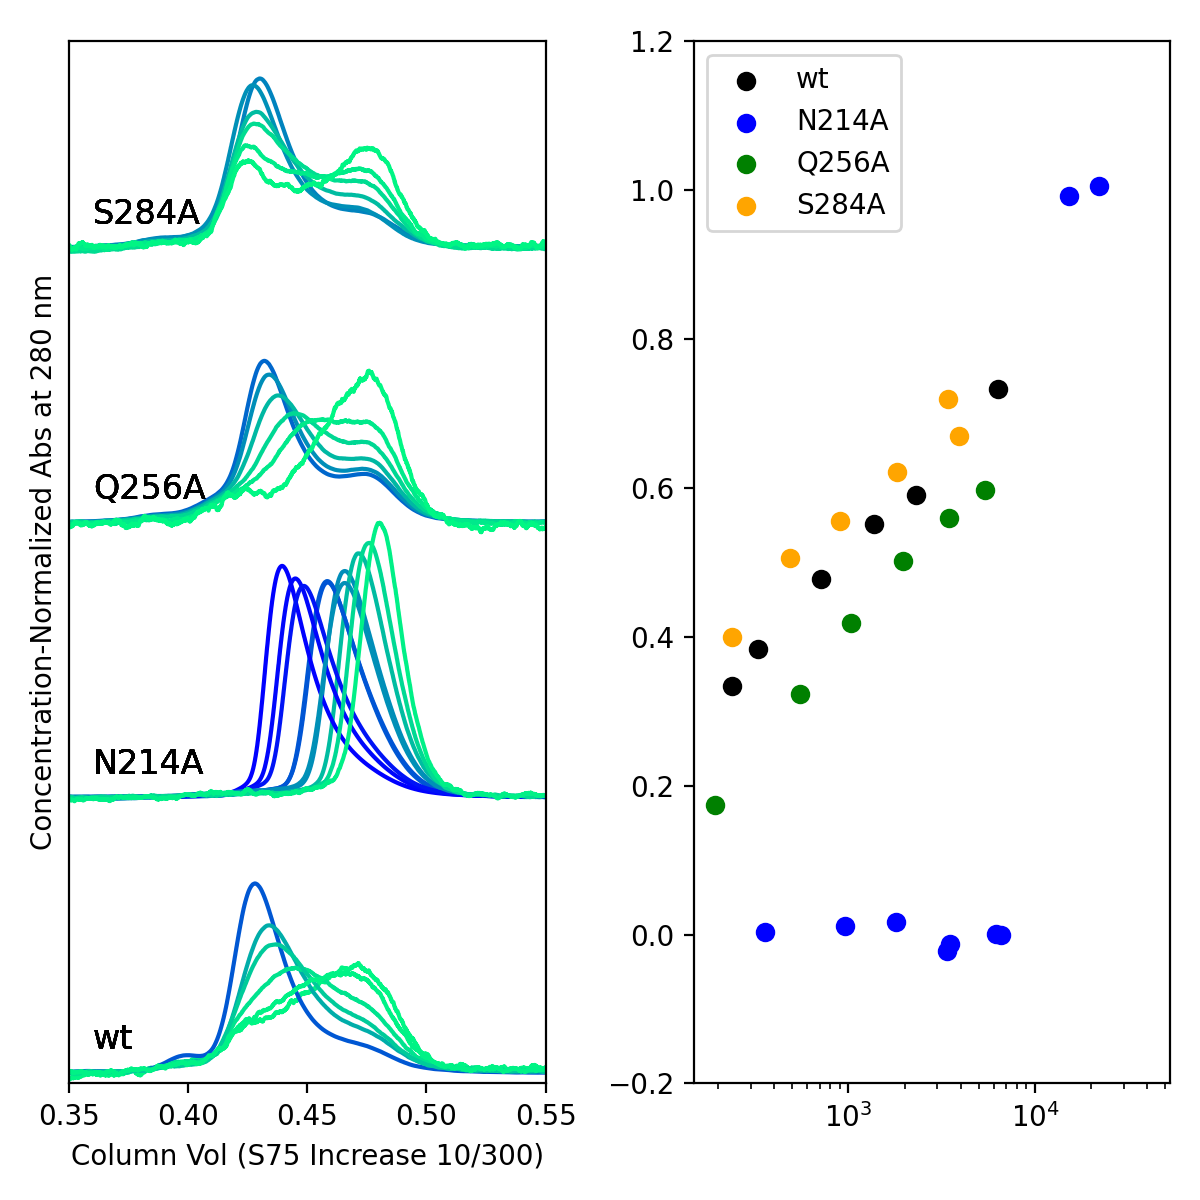

In [157]:
plt.figure(figsize=(6,6))

axL = plt.subplot(121)
axR = plt.subplot(122)

axR_legend = []

for im,m in enumerate(mutants):
    
    offset = im * 0.0024
    
    data = all_data[m]
    
    n_concs = data.shape[1] - 1
    colors = plt.cm.winter(np.logspace(0,-3,41000))
    
    CV = data[:,0] / 24.0
    
    # define the region to integrate 
    start = np.argmin(np.abs(CV - low_cv_cutoff))
    end   = np.argmin(np.abs(CV - hgh_cv_cutoff))
    
    for i in range(1, n_concs+1):

        UV = (data[:,i] - np.median(data[:,i]))

        auc = UV[start:end].sum()
        
        axL.plot(CV, UV / auc + offset, color=colors[round(auc)])
        axL.text(0.36, 2e-4 + offset, m, fontsize=12, fontweight=10)
        
        params, _ = fit_double_gaussian(CV[start:end], UV[start:end])
        r = ratio_area_under_gaussians(params)
        p = axR.scatter(auc, r, color=mutant_colors[im])
        
    axR_legend.append(p)
        
        
axL.set_xlim([0.35, 0.55])
axL.set_ylim([-0.0001, 0.009])
axL.set_yticks([])

axL.set_xlabel('Column Vol (S75 Increase 10/300)')
axL.set_ylabel('Concentration-Normalized Abs at 280 nm')

axR.set_ylim([-0.2, 1.2])
axR.set_xscale('log')
axR.legend(axR_legend, mutants)

#plt.vlines([p1, p2], 0.0, 3.0, 'k', linestyles='dashed')
#plt.legend(['{} $\mu$M'.format(c) for c in concs], loc=1, title='')

plt.tight_layout()
plt.show()

(array([0.16833169, 0.42      , 0.01238206, 0.2052313 , 0.47      ,
       0.01530236]), 1)


<IPython.core.display.Javascript object>


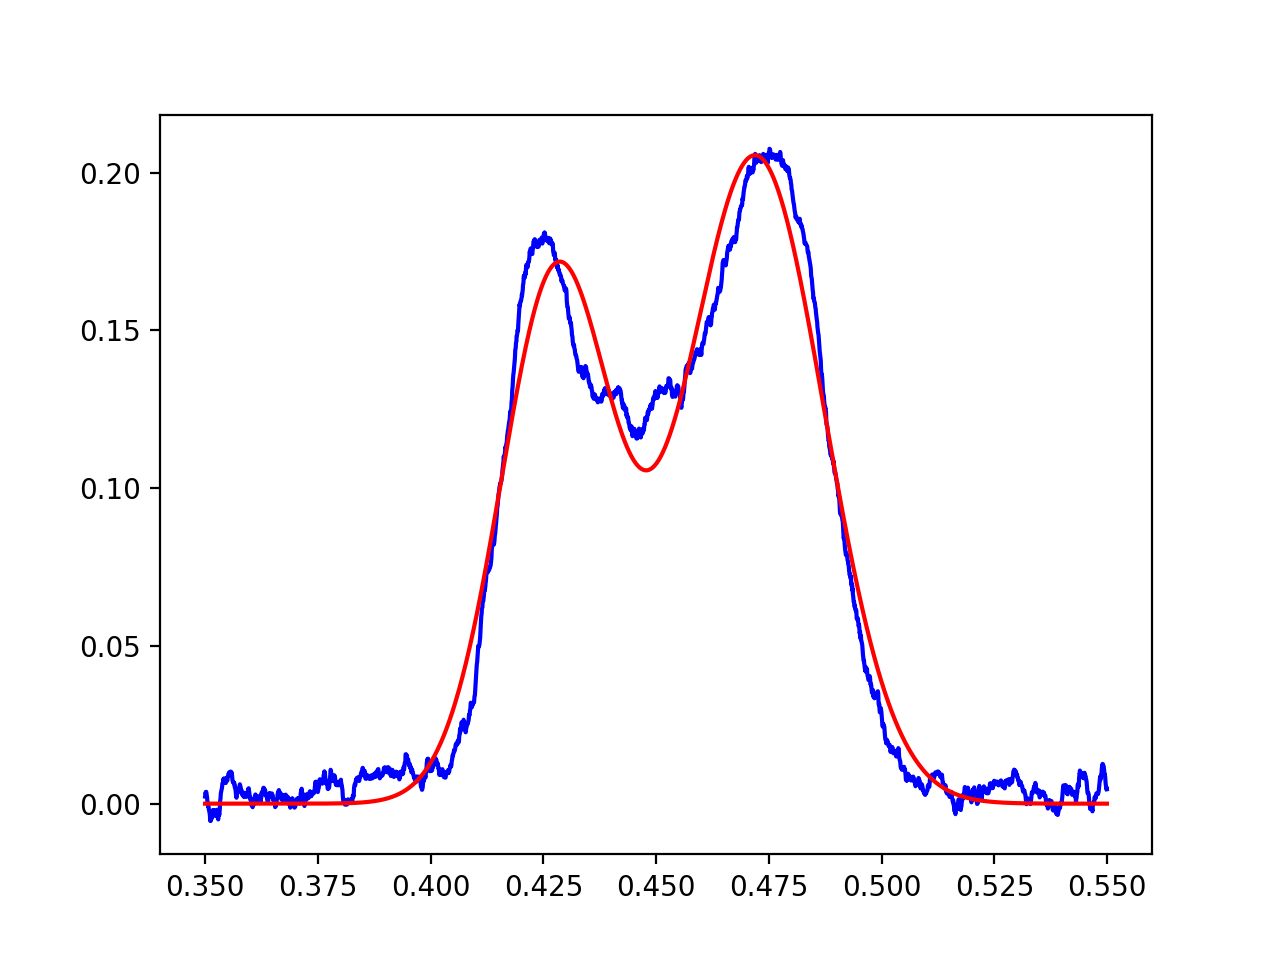

In [144]:
ii = 6

x = CV[start:end]
y = data[start:end,ii] - np.median(data[:,ii])

fit = fit_double_gaussian(x, y)
print(fit)

plt.figure()
plt.plot( x, y, c='b' )
plt.plot( x, double_gaussian(x, fit[0]), c='r' )
plt.show()